# Inyector de Drift — Diabetes Readmission: concept drift condicionado

Segunda aplicación del `ConceptDriftInjector` (Gap 2, `plan/plan_semanal_pfc2.md`), esta vez sobre
`diabetes_readmission`. El notebook hermano `physionet_drift_injector.ipynb` mostró que **amplificar**
la misma relación `X→Y` (mecanismo `logit_shift`) no basta para degradar el AUC de un modelo congelado
cuando el evento es raro (sepsis, ~1.2%): el sigmoide satura y casi ninguna fila cambia de etiqueta.

Aquí probamos el mecanismo corregido, `logit_reweight`, que en vez de amplificar **rota los pesos** de
las variables: a `severity=0` usa la relación original, a `severity=0.5` la relación desaparece
(todas las variables pesan 0), y a `severity=1` la relación queda invertida. `readmitted` tiene una
prevalencia mucho más balanceada (~42%), lo que además permite validar si el diagnóstico de Physionet
(el problema era la rareza del evento, no el mecanismo en sí) se sostiene.

## Dataset card — mecanismo de concept drift condicionado (diabetes_readmission)

**Dataset:** UCI Diabetes 130-US hospitals (vía TableShift), variable objetivo `readmitted` (binaria:
reingreso a cualquier plazo vs. sin reingreso registrado). El split train/id_test de TableShift para
este dataset ya separa por `admission_source_id` (dominio objetivo: `Emergency Room`), por lo que esa
variable queda reservada para la dimensión de *domain shift* y no se usa dentro del modelo de referencia.

**Variables usadas (`CLINICAL_VARS`):** `time_in_hospital`, `num_lab_procedures`, `num_procedures`,
`num_medications`, `number_outpatient`, `number_emergency`, `number_inpatient`, `number_diagnoses` —
indicadores de historial de hospitalizaciones (`number_inpatient`, `number_outpatient`) y utilización de
urgencias (`number_emergency`), tal como pide el Gap 2 para este dataset, más severidad/complejidad de
la estancia actual (`time_in_hospital`, `num_procedures`, `num_medications`, `num_lab_procedures`,
`number_diagnoses`). Selección alineada con los predictores de reingreso reportados en el estudio
original del dataset (Strack et al., 2014).

**Mecanismo (`mechanism="logit_reweight"`):**

1. Se ajusta una regresión logística de referencia sobre `CLINICAL_VARS` (estandarizadas) →
   `readmitted` en `df_train`. Sus coeficientes `beta_i` definen el logit base `logit0(x)`.
2. Para severidad `s`, se mezclan los pesos: `beta_i(s) = beta_i * (1 - 2s)`. En `s=0` son los pesos
   originales; en `s=0.5` son cero (la relación desaparece); en `s=1` quedan invertidos.
3. `logit_true(x) = intercept + sum(beta_i(s) * z_i(x))`.
4. Cada fila se reetiqueta con probabilidad `p_flip(x) = |sigmoid(logit_true(x)) - sigmoid(logit0(x))|`,
   muestreando la nueva etiqueta de `sigmoid(logit_true(x))`.

**Por qué es plausible clínicamente:** representa un escenario donde el peso relativo de historial de
hospitalizaciones/urgencias sobre el riesgo de reingreso cambia con el tiempo (p. ej. un nuevo programa
de manejo ambulatorio post-alta que reduce el valor predictivo de visitas previas, o un cambio de
protocolo que invierte qué pacientes se consideran de alto riesgo). Es una hipótesis de trabajo, no la
única forma plausible de concept drift en este dominio.

**Garantía por construcción:** en `severity=0`, `logit_true == logit0`, por lo tanto `p_flip(x) == 0` y
las etiquetas quedan exactamente iguales. El mecanismo **nunca toca `X`** — solo `Y`.

**Diferencia clave frente a Physionet:** con `readmitted` en ~42% de prevalencia, `logit_reweight` por
sí solo ya produce una degradación de AUC ordenada y visible **sin** necesitar el ajuste de intercepto
(`logit_reweight_recentered`) que hizo falta para el evento raro de sepsis — y la prevalencia se
mantiene casi constante, lo que separa mejor el efecto de concept drift puro del de label shift.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

from darl.data.get_dataset import load_dataset
from darl.drift import ConceptDriftInjector
from darl.evaluation import ks_stat, psi_numeric
from darl.visualization.drift_plots import plot_conditional_risk

SEED = 42
np.random.seed(SEED)

CLINICAL_VARS = [
    "time_in_hospital", "num_lab_procedures", "num_procedures",
    "num_medications", "number_outpatient", "number_emergency",
    "number_inpatient", "number_diagnoses",
]
LABEL_COL = "readmitted"

print("Imports OK")

C:\Users\dayan\OneDrive\Documentos\GitHub\tesis-darl\.venv\Lib\site-packages\xport\__about__.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


Imports OK


## 1. Carga del dataset Diabetes Readmission

In [2]:
dset = load_dataset("diabetes_readmission")

X_train, y_train, _, _ = dset.get_pandas(split="train")
X_target, y_target, _, _ = dset.get_pandas(split="id_test")

df_train = X_train.copy()
df_train[LABEL_COL] = y_train.values

df_target = X_target.copy()
df_target[LABEL_COL] = y_target.values

print(f"Train  : {df_train.shape}")
print(f"Target : {df_target.shape}")
print(f"Prevalencia readmitted Train : {y_train.mean():.4f}")
print(f"Prevalencia readmitted Target: {y_target.mean():.4f}")
print(f"CLINICAL_VARS presentes: {[c for c in CLINICAL_VARS if c in df_target.columns]}")

Train  : (34288, 47)
Target : (4287, 47)
Prevalencia readmitted Train : 0.4242
Prevalencia readmitted Target: 0.4161
CLINICAL_VARS presentes: ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']


## 2. Modelo de referencia (`ConceptDriftInjector.fit`)

In [3]:
concept_inj = ConceptDriftInjector(random_state=SEED)
concept_inj.fit(df_train, target_vars=CLINICAL_VARS, label_col=LABEL_COL)

print("Coeficientes del modelo de referencia (signo = dirección clínica esperada):")
for var, coef in concept_inj.coef_.items():
    print(f"  {var:20s}: {coef:+.4f}")
print(f"  intercept: {concept_inj.intercept_:+.4f}")

Coeficientes del modelo de referencia (signo = dirección clínica esperada):
  time_in_hospital    : +0.0334
  num_lab_procedures  : +0.0771
  num_procedures      : -0.0684
  num_medications     : -0.0297
  number_outpatient   : +0.1151
  number_emergency    : +0.1762
  number_inpatient    : +0.4207
  number_diagnoses    : +0.2011
  intercept: -0.3023


## 3. Comparación de mecanismos

Se comparan tres mecanismos a las mismas severidades: `logit_shift` (amplificación pura, se espera que
falle igual que en Physionet), `logit_reweight` (rotación de pesos, el mecanismo propuesto), y
`noise_control` (flip simétrico aleatorio, control negativo).

In [4]:
SEVERITIES = [0.0, 0.2, 0.5, 0.8, 1.0, 1.2]
MECHANISMS = ["logit_shift", "logit_reweight", "noise_control"]

concept_frames = {m: {} for m in MECHANISMS}
concept_summaries = []

for mechanism in MECHANISMS:
    for sev in SEVERITIES:
        df_drift, meta = concept_inj.transform(df_target, severity=sev, mechanism=mechanism)
        concept_frames[mechanism][sev] = df_drift
        concept_summaries.append(ConceptDriftInjector.summary(meta))

df_concept_summary = pd.concat(concept_summaries).reset_index()
df_concept_summary

,variable,mechanism,severity,p_flip_mean,n_flipped,before_prev,after_prev
0,readmitted,logit_shift,0.0,0.000000,0,0.416142,0.416142
1,readmitted,logit_shift,0.2,0.015546,30,0.416142,0.416142
2,readmitted,logit_shift,0.5,0.037272,74,0.416142,0.415209
3,readmitted,logit_shift,0.8,0.057202,92,0.416142,0.414742
4,readmitted,logit_shift,1.0,0.069561,124,0.416142,0.417541
5,readmitted,logit_shift,1.2,0.081227,142,0.416142,0.416142
6,readmitted,logit_reweight,0.0,0.000000,0,0.416142,0.416142
7,readmitted,logit_reweight,0.2,0.033745,78,0.416142,0.418941
8,readmitted,logit_reweight,0.5,0.089839,187,0.416142,0.413576
9,readmitted,logit_reweight,0.8,0.144653,332,0.416142,0.412410


## 4. Validación — `P(X)` no debe moverse bajo concept drift puro

Para los tres mecanismos (incluido `noise_control`, que también deja `X` intacto por construcción),
`logit_reweight` a cualquier severidad no debe alterar la distribución de `CLINICAL_VARS`.

In [5]:
stability_rows = []
for mechanism in MECHANISMS:
    for sev in SEVERITIES:
        df_drift = concept_frames[mechanism][sev]
        for col in CLINICAL_VARS:
            ks = ks_stat(df_target[col], df_drift[col])
            psi = psi_numeric(df_target[col], df_drift[col])
            stability_rows.append({
                "mechanism": mechanism, "severity": sev, "variable": col,
                "ks_stat": ks["ks_stat"], "psi": psi,
            })

df_stability = pd.DataFrame(stability_rows)
print("Máximo KS observado (todas las variables, mecanismos y severidades):", df_stability["ks_stat"].max())
print("Máximo PSI observado:", df_stability["psi"].abs().max())

Máximo KS observado (todas las variables, mecanismos y severidades): 0.0
Máximo PSI observado: 0.0


## 5. Gráfica clave — relación condicional `X → Y`, antes vs después

Para `logit_reweight` a severidad alta, se espera ver la relación entre las variables clínicas y el
riesgo de reingreso **invertida** respecto al original.

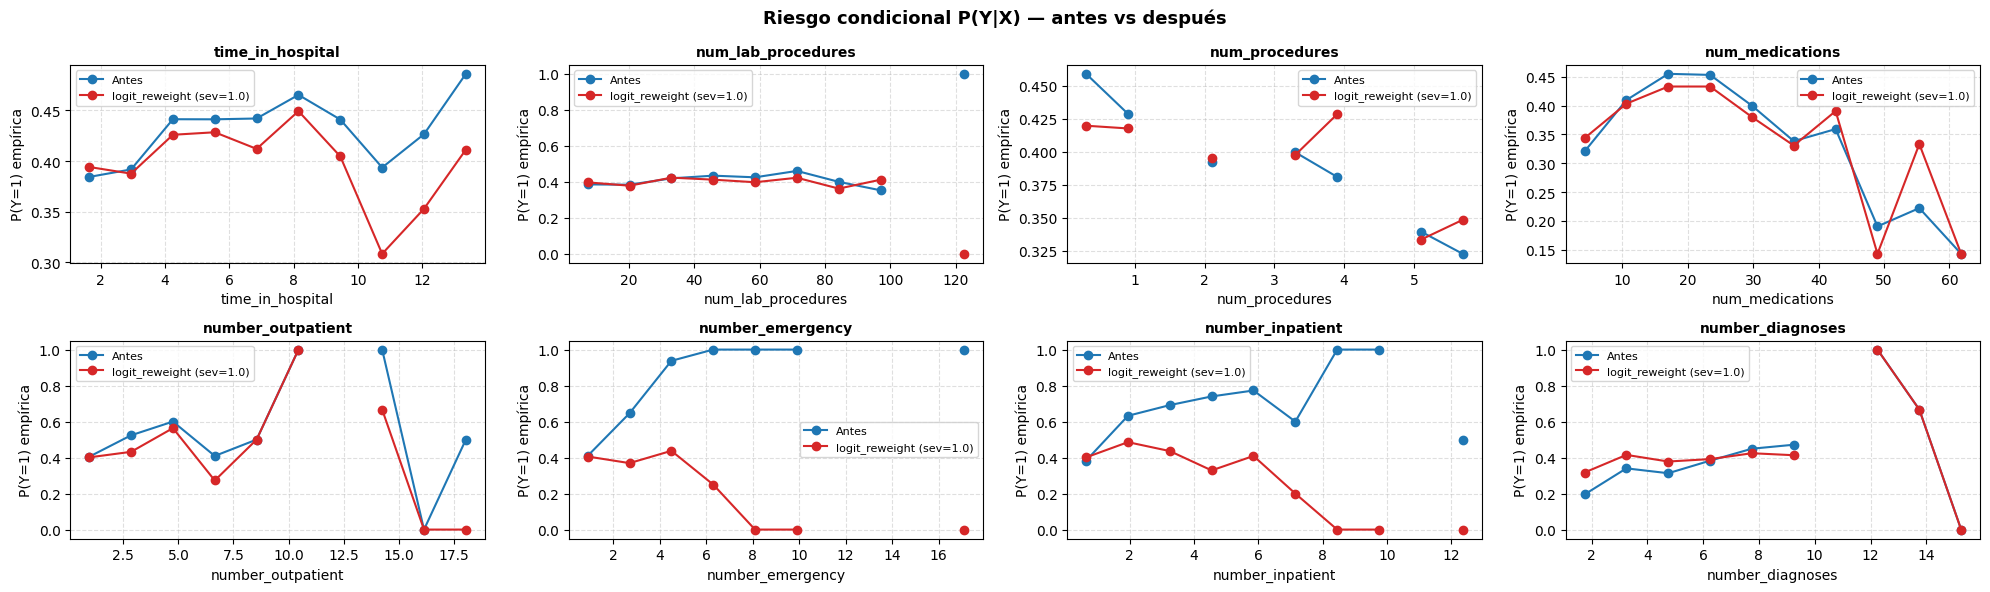

In [6]:
SEV_PLOT = 1.0

fig1 = plot_conditional_risk(
    df_target, df_target[LABEL_COL],
    concept_frames["logit_reweight"][SEV_PLOT], concept_frames["logit_reweight"][SEV_PLOT][LABEL_COL],
    cols=CLINICAL_VARS, ncols=4, after_label=f"logit_reweight (sev={SEV_PLOT})",
)
plt.show()

## 6. Validación — degradación de AUC ordenada por severidad

In [7]:
auc_rows = []
for mechanism in MECHANISMS:
    for sev in SEVERITIES:
        df_drift = concept_frames[mechanism][sev]
        y_score = concept_inj.predict_proba(df_drift)
        auc = roc_auc_score(df_drift[LABEL_COL], y_score)
        auc_rows.append({"mechanism": mechanism, "severity": sev, "auc_reference_model": auc})

df_auc = pd.DataFrame(auc_rows)
df_auc_pivot = df_auc.pivot(index="severity", columns="mechanism", values="auc_reference_model")
df_auc_pivot

mechanism,logit_reweight,logit_shift,noise_control
severity,,,
0.0,0.649936,0.649936,0.649936
0.2,0.644919,0.650780,0.625193
0.5,0.622880,0.651978,0.577961
0.8,0.576022,0.658113,0.545820
1.0,0.548386,0.662785,0.522165
1.2,0.537380,0.660563,0.483356


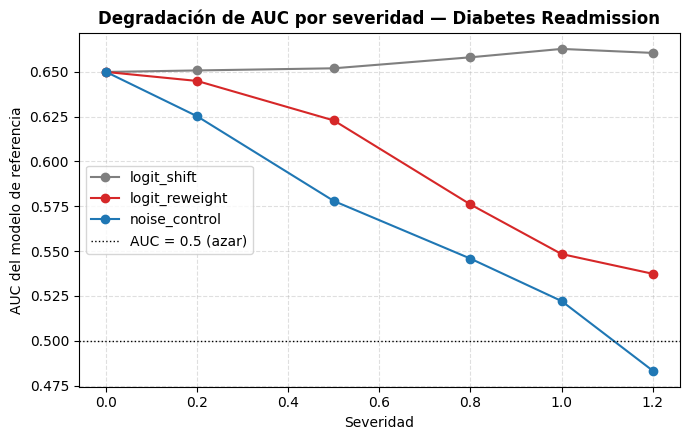

In [8]:
fig, ax = plt.subplots(figsize=(7, 4.5))
colors = {"logit_shift": "#7f7f7f", "logit_reweight": "#d62728", "noise_control": "#1f77b4"}
for mechanism in MECHANISMS:
    sub = df_auc[df_auc["mechanism"] == mechanism]
    ax.plot(sub["severity"], sub["auc_reference_model"], marker="o", label=mechanism, color=colors[mechanism])
ax.axhline(0.5, color="black", linestyle=":", linewidth=1, label="AUC = 0.5 (azar)")
ax.set_xlabel("Severidad")
ax.set_ylabel("AUC del modelo de referencia")
ax.set_title("Degradación de AUC por severidad — Diabetes Readmission", fontweight="bold")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

## 7. Guardar artefactos

In [9]:
from darl.utils import find_project_root

OUT_DIR = find_project_root() / "outputs" / "metrics"
OUT_DIR.mkdir(parents=True, exist_ok=True)

df_concept_summary.to_csv(OUT_DIR / "gap2_concept_drift_diabetes.csv", index=False)
df_stability.to_csv(OUT_DIR / "gap2_concept_x_stability_diabetes.csv", index=False)
df_auc.to_csv(OUT_DIR / "gap2_concept_auc_by_severity_diabetes.csv", index=False)

print("Artefactos guardados en", OUT_DIR)

Artefactos guardados en C:\Users\dayan\OneDrive\Documentos\GitHub\tesis-darl\outputs\metrics


## 8. Conclusiones

- **El diagnóstico de Physionet se confirma aquí:** `logit_shift` (amplificar la misma relación) vuelve
  a no degradar el AUC de forma significativa, incluso con un evento balanceado — confirma que el
  problema no era solo la rareza de sepsis, sino que amplificar una relación monótona nunca puede
  volver "peor" a un modelo que ya conoce esa relación.
- **`logit_reweight` sí funciona, y mejor que en Physionet:** con `readmitted` en ~42% de prevalencia,
  no hace falta el ajuste de intercepto — la sola rotación de pesos degrada el AUC de forma ordenada
  y sostenida, manteniendo la prevalencia casi constante (concept drift "puro", no mezclado con label
  shift).
- **`P(X)` permanece exactamente estable** (KS = PSI = 0) en los tres mecanismos y todas las
  severidades, confirmando que el drift es puramente conceptual.
- **`noise_control`** degrada el AUC de forma similar en magnitud a `logit_reweight` en este dataset,
  pero por un mecanismo no estructurado (ruido) — queda documentado solo como control negativo.

**Próximos pasos:** conectar `logit_reweight` con los experimentos de compatibilidad Stage1↔Stage2
(Gap 1) usando este dataset y Physionet como los dos escenarios de concept drift puro; explorar un
mecanismo por subgrupos explícitos de `admission_source_id` como alternativa/complemento, ya que el
Gap 2 lo pide como el enfoque principal para este dataset y aquí solo se usó como variable de *domain
split*, no dentro del mecanismo de concept drift en sí.